In [104]:
!pip -q install stratify

In [134]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

In [4]:
overpass_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass"

In [5]:
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [6]:
overpass_files[0]

PosixPath('/home/jovyan/my-public-bucket/orcestra/overpass/overpass_00000_01150A.nc')

In [10]:
dt = xr.open_datatree(overpass_files[0])

In [11]:
dt

<xarray.DataTree>
Group: /
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 21, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 168B ...
│           latitude                          (along_track) float64 168B ...
│           longitude                         (along_track) float64 168B ...
│         * height                            (height) float64 2kB 1.995e+04 ... 50.0
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 34kB ...
│           CPR_ATLID_status                  (along_track, height) float64 34kB ...
│           quality_status                    (along_track, height) float64 34kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240810T203032Z_20250904T221535Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 21, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 168B ...
│           latitude                                    (along_track) float64 168B ...
│           longitude                                   (along_track) float64 168B ...
│         * height                                      (height) float64 2kB 1.995e+0...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 84B ...
│           synergy_status                              (along_track) int8 21B ...
│           quality_status                              (along_track) int8 21B ...
│           ice_extinction                              (along_track, height) float32 17kB ...
│           ice_riming_index                            (along_track, height) float32 17kB ...
│           ice_riming_index_error                      (along_track, height) float32 17kB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 17kB ...
│           aerosol_extinction                          (along_track, height) float32 17kB ...
│           aerosol_extinction_error                    (along_track, height) float32 17kB ...
│           aerosol_optical_depth                       (along_track) float32 84B ...
│           aerosol_optical_depth_error                 (along_track) float32 84B ...
│           CPR_doppler_velocity                        (along_track, height) float32 17kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_ACM_CAP_2B_20240810T203032Z_20250905T220717Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         ACM_CAP_2B
│           File_Version:      0001
├── Group: /ACM_RT__2B
│       Dimensions:                                      (along_track: 21,
│                                                         atmosphere_1d: 1,
│                                                         height_level: 249,
│                                                         height_layer: 248,
│                                                         atmosphere_3d: 1, height: 200)
│       Coordinates:
│           time                                         (along_track) datetime64[ns] 168B ...
│           latitude                                     (along_track) float32 84B ...
│           longitude                                    (along_track) float32 84B ...
│         * height                                       (height) float64 2kB 1.995e+...
│  

In [43]:
dt.CPR_FMR_2A.quality_status

<xarray.DataArray 'quality_status' (along_track: 21, height: 200)> Size: 17kB
array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(21, 200), dtype=float32)
Coordinates:
    time       (along_track) datetime64[ns] 168B ...
    latitude   (along_track) float64 168B ...
    longitude  (along_track) float64 168B ...
  * height     (height) float64 2kB 1.995e+04 1.985e+04 1.975e+04 ... 150.0 50.0
Dimensions without coordinates: along_track
Attributes:
    long_name:   Feature mask and reflectivity quality status
    definition:  0 = good, 1 = bad
    comment:     This flag indicates where the reflectivity measurements are ...

In [44]:
QUALITY_THRESH = dict(
    AC__TC__2B=9,
    ACM_CAP_2B=7,
    ACM_RT__2B=3,
    ALL_DF__2B=1,
    ATL_EBD_2A=1,
    CPR_CD__2A=0,
    CPR_FMR_2A=0,
)

In [18]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

In [19]:
from products import PRODUCTS

In [27]:
list(PRODUCTS.keys())

['AC__TC__2B',
 'ACM_CAP_2B',
 'ACM_RT__2B',
 'ALL_DF__2B',
 'ATL_EBD_2A',
 'CPR_CD__2A',
 'CPR_FMR_2A']

In [45]:
column_datasets = [
    (
        dt[product].to_dataset().where(dt[product]["quality_status"]<=QUALITY_THRESH[product]).mean("along_track") 
        if "quality_status" in dt[product].data_vars
        else dt[product].mean("along_track")
    ) for product in  PRODUCTS
]

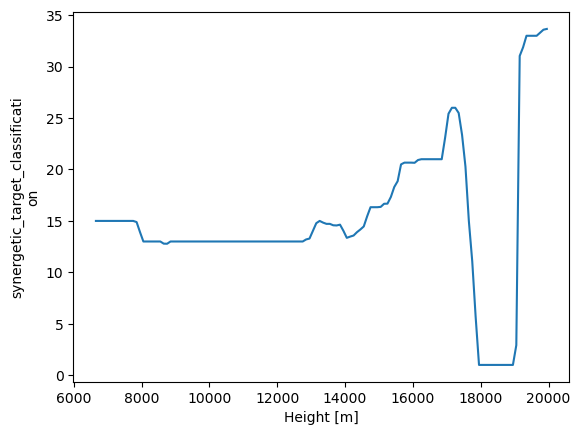

In [48]:
column_datasets[0].synergetic_target_classification.plot()

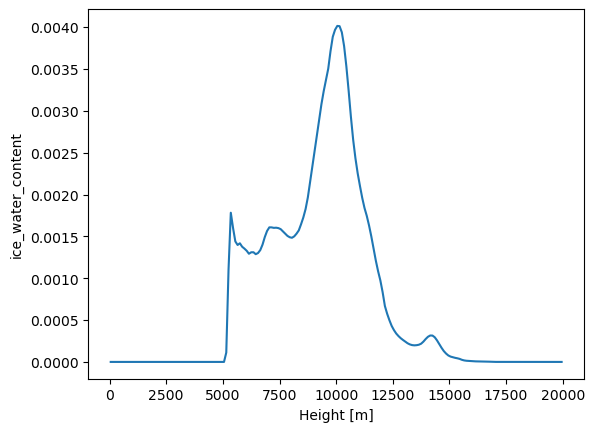

In [46]:
column_datasets[1].ice_water_content.plot()

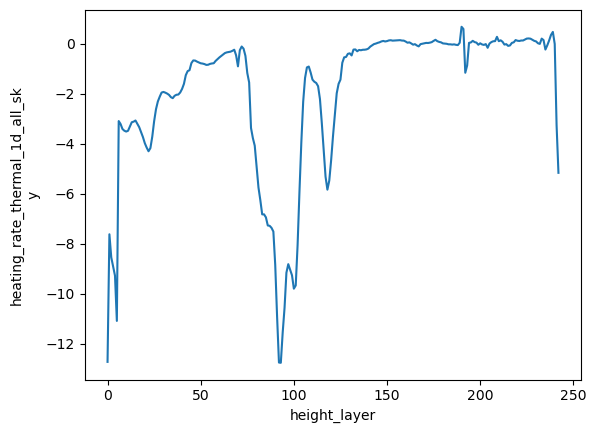

In [50]:
column_datasets[2].heating_rate_thermal_1d_all_sky.plot()

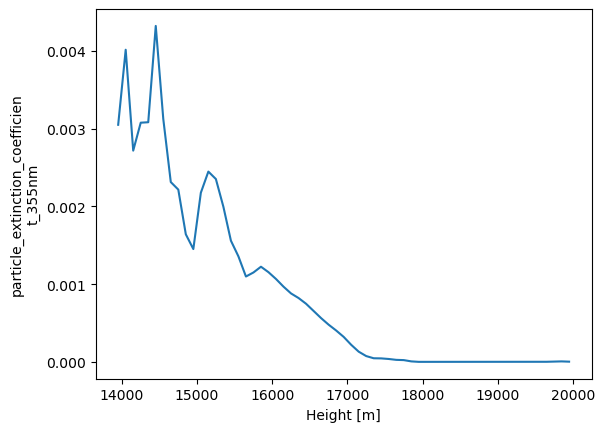

In [59]:
column_datasets[4].particle_extinction_coefficient_355nm.plot()

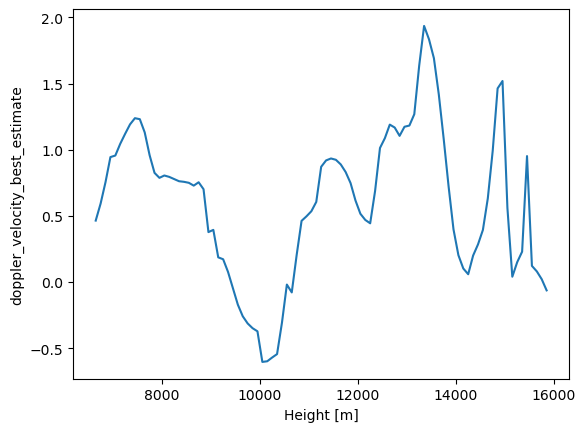

In [63]:
column_datasets[5].doppler_velocity_best_estimate.plot()

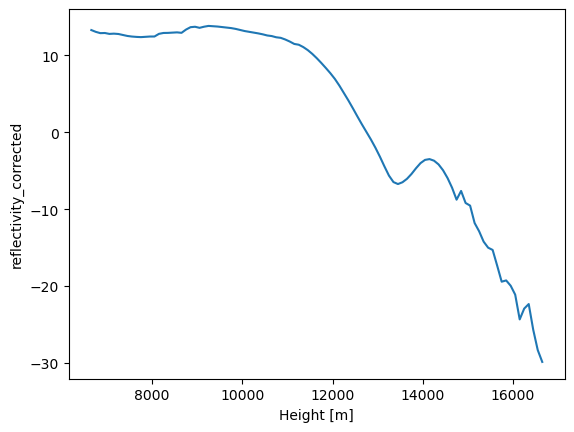

In [65]:
column_datasets[6].reflectivity_corrected.plot()

In [67]:
coloc_gdf = gpd.read_parquet("orcestra_coloc_ec_sounders.parquet")

In [69]:
coloc_gdf.time_cell

0     0 days 00:00:00
1     0 days 00:00:00
2     0 days 00:00:00
3     0 days 00:00:00
4     0 days 00:00:00
            ...      
974   0 days 00:00:00
975   0 days 00:30:00
976   0 days 00:00:00
977   0 days 00:00:00
978   0 days 00:00:00
Name: time_cell, Length: 979, dtype: timedelta64[ns]

In [74]:
coloc_gdf.time[int(overpass_files[0].name.split("_")[1])]

Timestamp('2024-08-10 20:30:00')

In [73]:
coloc_gdf.time_cell[int(overpass_files[0].name.split("_")[1])]

Timedelta('0 days 00:00:00')

In [79]:
dt.ACM_CAP_2B.time.mean()

<xarray.DataArray 'time' ()> Size: 8B
array('2024-08-10T20:39:32.527589577', dtype='datetime64[ns]')

In [86]:
index = int(overpass_files[0].name.split("_")[1])
ec_time_diff = pd.to_datetime(dt.ACM_CAP_2B.time.mean().values) - (coloc_gdf.time[index] - coloc_gdf.time_cell[index])

In [87]:
ec_time_diff

Timedelta('0 days 00:09:32.527589577')

In [92]:
dt.noaa_20.obs_time_tai93.mean()

<xarray.DataArray 'obs_time_tai93' ()> Size: 8B
array('2024-08-10T20:37:09.348236846', dtype='datetime64[ns]')

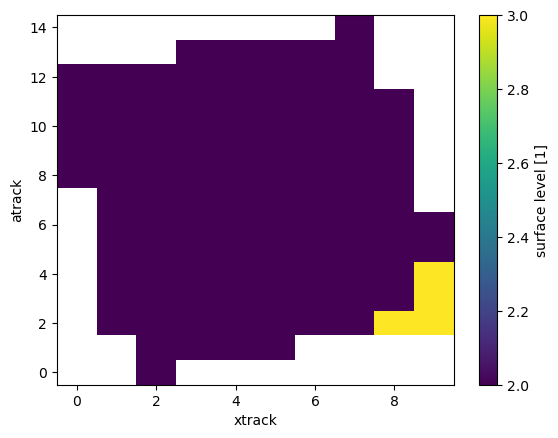

In [114]:
dt.noaa_20.air_pres_stand_nsurf.plot()

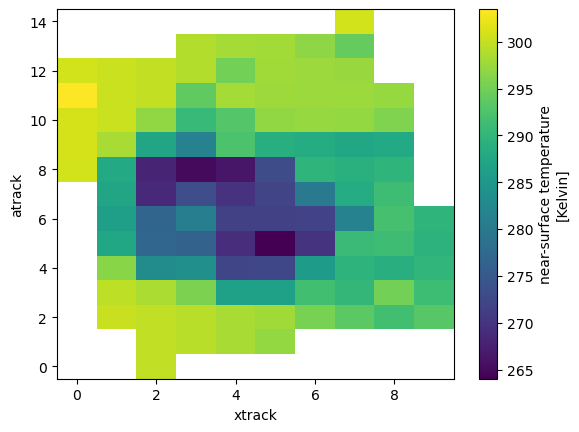

In [93]:
dt.noaa_20.surf_air_temp.plot()

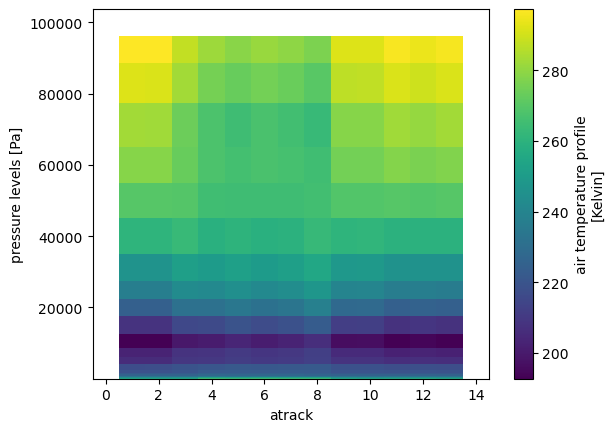

In [102]:
dt.noaa_20.air_temp[:,4].T.plot()

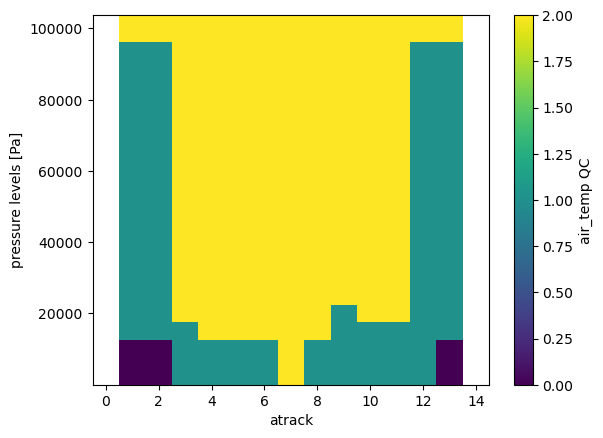

In [103]:
dt.noaa_20.air_temp_qc[:,4].T.plot()

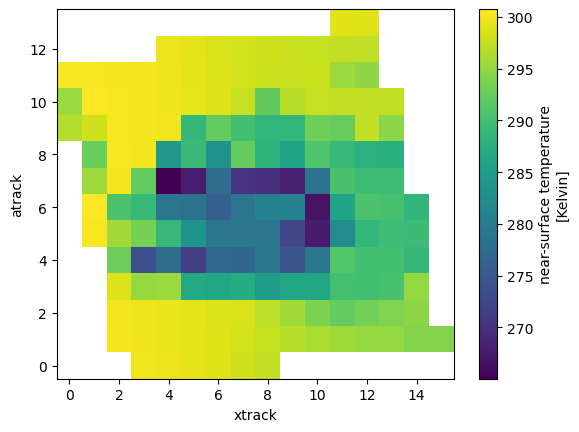

In [95]:
dt.snpp.surf_air_temp.plot()

In [97]:
dt.noaa_20.surf_temp_qc

<xarray.DataArray 'surf_temp_qc' (atrack: 15, xtrack: 10)> Size: 600B
[150 values with dtype=float32]
Coordinates:
    lat         (atrack, xtrack) float32 600B ...
    lon         (atrack, xtrack) float32 600B ...
    subsat_lat  (atrack) float32 60B ...
    subsat_lon  (atrack) float32 60B ...
Dimensions without coordinates: atrack, xtrack
Attributes:
    long_name:              surf_temp QC
    AIRS_HDF_name:          TSurfStd_QC
    flag_meanings:          Best Good Do_Not_Use
    flag_values:            [0 1 2]
    standard_name:          surface_temperature status_flag
    coverage_content_type:  qualityInformation
    valid_range:            [0 2]
    description:            surf_temp QC flag